<a href="https://colab.research.google.com/github/tegarpng/Projek-Kelompok-29/blob/main/Percobaan1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od

# Masukkan link URL dataset Kaggle langsung di sini
od.download("https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: alfatih2401
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data


100%|██████████| 151M/151M [00:01<00:00, 128MB/s]


In [14]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [18]:
import os
import cv2 as cv
import numpy as np

data = []
labels = []
file_name = []

# Batasi 300 gambar per folder agar pengerjaan cepat & seimbang
class_counters = {'Brain Tumor': 0, 'Healthy': 0, 'glioma': 0, 'notumor': 0}
dataset_path = "brain-tumor-mri-data"

for root, dirs, files in os.walk(dataset_path):
    folder_aktif = os.path.basename(root)
    if folder_aktif in ['Brain Tumor', 'Healthy', 'glioma', 'notumor']:
        for filename in files:
            if class_counters[folder_aktif] >= 300:
                break
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(root, filename)
                img = cv.imread(img_path)
                if img is not None:
                    # Sesuai template: cuma Grayscale (Resize & Equalization di tahap berikutnya)
                    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

                    data.append(img_gray)
                    labels.append(folder_aktif)
                    file_name.append(filename)
                    class_counters[folder_aktif] += 1

data = np.array(data, dtype=object)
labels = np.array(labels)
print(f"Sukses membaca data mentah! Total data awal: {len(data)} gambar.")

Sukses membaca data mentah! Total data awal: 600 gambar.


In [43]:
data_augmented = []
labels_augmented = []
file_name_augmented = []

for i in range(len(data)):
    img_asli = data[i]
    label_asli = labels[i]
    nama_asli = file_name[i]

    data_augmented.append(img_asli)
    labels_augmented.append(label_asli)
    file_name_augmented.append(f"asli_{nama_asli}")

    img_flip = img_asli[:, ::-1]
    data_augmented.append(img_flip)
    labels_augmented.append(label_asli)
    file_name_augmented.append(f"flip_{nama_asli}")

    img_rot = img_asli.T[:, ::-1]
    data_augmented.append(img_rot)
    labels_augmented.append(label_asli)
    file_name_augmented.append(f"rot90_{nama_asli}")

data_augmented = np.array(data_augmented, dtype=object)
labels_augmented = np.array(labels_augmented)

print("--- Augmentasi Selesai! ---")

--- Augmentasi Selesai! ---


In [20]:
def grayscale(image):
    if len(image.shape) == 3:
        return cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    return image

def resize(image, target_size):
    return cv.resize(image, target_size)

def equalization_manual(image):
    hist, bins = np.histogram(image.flatten(), bins=256, range=[0,256])
    cdf = hist.cumsum()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')
    img_equalized = cdf_final[image]
    return img_equalized

Sedang mengeksekusi Preprocessing Percobaan 1...
--- Selesai! ---
Total citra hasil Percobaan 1: 1800 gambar.


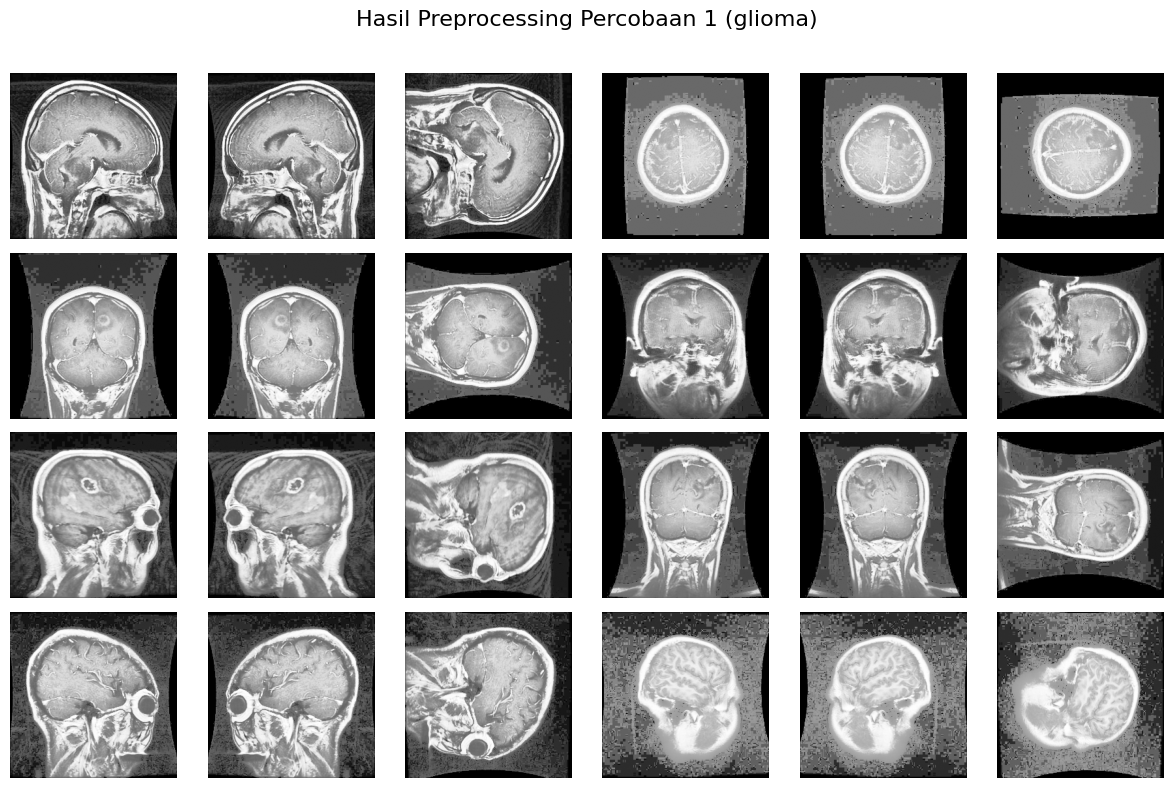

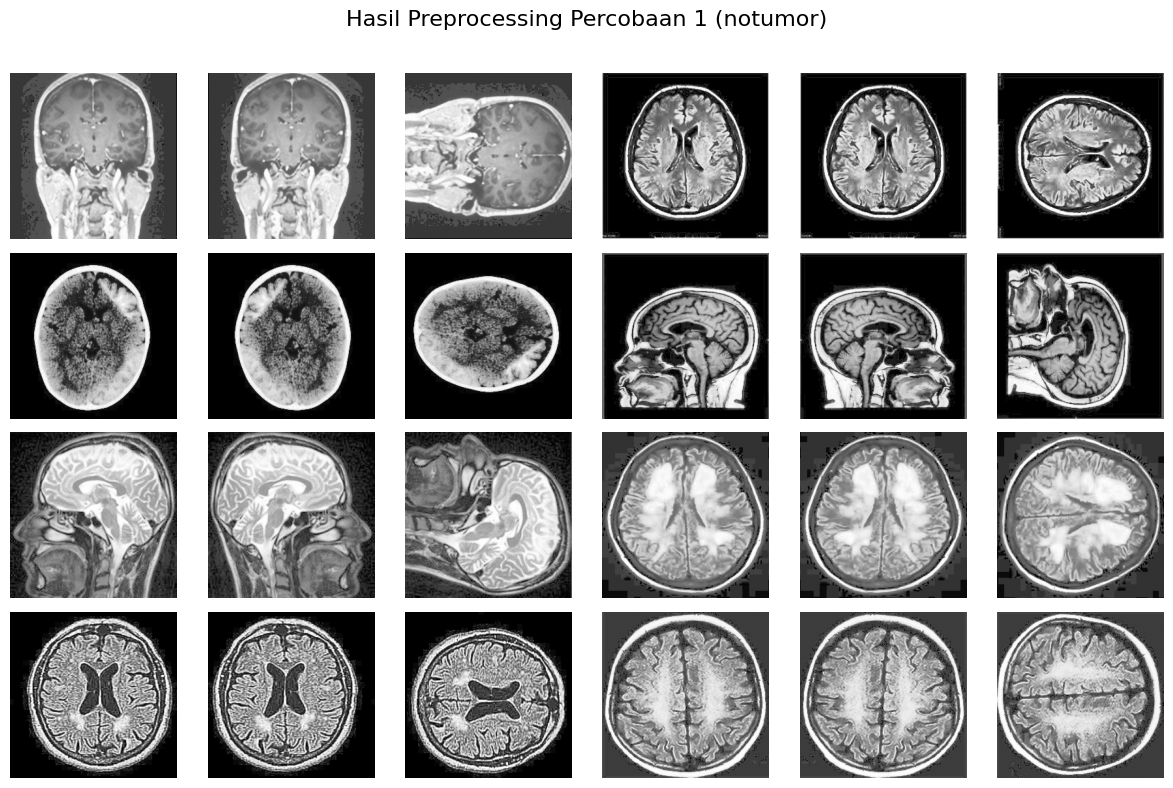

In [22]:
def percobaan1(image):
    img_gray = grayscale(image)
    img_resize = resize(img_gray, (256, 256))
    img_equalized = equalization_manual(img_resize)
    return img_equalized

dataPreprocessed = []

print("Sedang mengeksekusi Preprocessing Percobaan 1...")

for i in range(len(data_augmented)):
    img_hasil = percobaan1(data_augmented[i])
    dataPreprocessed.append(img_hasil)

dataPreprocessed = np.array(dataPreprocessed)

print("--- Selesai! ---")
print(f"Total citra hasil Percobaan 1: {len(dataPreprocessed)} gambar.")

unique_labels = sorted(set(labels_augmented))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels_augmented) if l == label]

    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'Hasil Preprocessing Percobaan 1 ({label})', fontsize=16)

    for k in range(24):
        row = k // 6
        col = k % 6
        ax = axs[row][col]

        img_idx = idxs[k]
        ax.imshow(dataPreprocessed[img_idx], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

In [24]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)

    return glcm

In [25]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [29]:
# Fungsi ekstraksi fitur untuk list citra
def ekstrak_fitur_glcm(data, nama_prepro):
    fitur_list = []
    for img in data:
        img_u8 = img.astype(np.uint8)
        m = glcm(img_u8, 0)  # derajat 0

        fitur = {
            'contrast': contrast(m),
            'correlation': correlation(m),
            'energy': energy(m),
            'homogeneity': homogenity(m),
            'dissimilarity': dissimilarity(m),
            'ASM': ASM(m),
            'entropy': entropyGlcm(m)
        }
        fitur_list.append(fitur)

    df = pd.DataFrame(fitur_list)
    df['tahap'] = nama_prepro
    return df

df2 = ekstrak_fitur_glcm(dataPreprocessed, 'percobaan1')
display(df2)

,contrast,correlation,energy,homogeneity,dissimilarity,ASM,entropy,tahap
0,210.226547,0.974898,0.218993,0.432847,6.978600,0.047958,6.456524,percobaan1
1,210.226547,0.974898,0.218993,0.432847,6.978600,0.047958,6.456524,percobaan1
2,116.063879,0.986233,0.222792,0.472382,5.197518,0.049636,6.259999,percobaan1
3,927.928462,0.933823,0.402892,0.501736,13.096967,0.162322,5.199847,percobaan1
4,927.928462,0.933823,0.402892,0.501736,13.096967,0.162322,5.199847,percobaan1
...,...,...,...,...,...,...,...,...
1795,400.273376,0.961698,0.107281,0.336406,11.034498,0.011509,6.730097,percobaan1
1796,358.746691,0.965698,0.107931,0.336159,10.405423,0.011649,6.675951,percobaan1
1797,356.907521,0.965159,0.120401,0.348248,10.078477,0.014496,6.766383,percobaan1
1798,356.907521,0.965159,0.120401,0.348248,10.078477,0.014496,6.766383,percobaan1


In [23]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(data)):
    D0 = glcm(data[i], 0)
    D45 = glcm(data[i], 45)
    D90 = glcm(data[i], 90)
    D135 = glcm(data[i], 135)

    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

print("--- Sukses membuat matriks derajat sudut GLCM! ---")

--- Sukses membuat matriks derajat sudut GLCM! ---


In [33]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

In [30]:
features = []

for i in range(len(dataPreprocessed)):
    fitur = [
        contrast(Derajat0[i]), contrast(Derajat45[i]), contrast(Derajat90[i]), contrast(Derajat135[i]),
        dissimilarity(Derajat0[i]), dissimilarity(Derajat45[i]), dissimilarity(Derajat90[i]), dissimilarity(Derajat135[i]),
        homogenity(Derajat0[i]), homogenity(Derajat45[i]), homogenity(Derajat90[i]), homogenity(Derajat135[i]),
        entropyGlcm(Derajat0[i]), entropyGlcm(Derajat45[i]), entropyGlcm(Derajat90[i]), entropyGlcm(Derajat135[i]),
        ASM(Derajat0[i]), ASM(Derajat45[i]), ASM(Derajat90[i]), ASM(Derajat135[i]),
        energy(Derajat0[i]), energy(Derajat45[i]), energy(Derajat90[i]), energy(Derajat135[i]),
        correlation(Derajat0[i]), correlation(Derajat45[i]), correlation(Derajat90[i]), correlation(Derajat135[i]),
    ]
    features.append(fitur)

# Buat dataframe
columns = [
    "contrast_0", "contrast_45", "contrast_90", "contrast_135",
    "dissimilarity_0", "dissimilarity_45", "dissimilarity_90", "dissimilarity_135",
    "homogeneity_0", "homogeneity_45", "homogeneity_90", "homogeneity_135",
    "entropy_0", "entropy_45", "entropy_90", "entropy_135",
    "ASM_0", "ASM_45", "ASM_90", "ASM_135",
    "energy_0", "energy_45", "energy_90", "energy_135",
    "correlation_0", "correlation_45", "correlation_90", "correlation_135"
]

df_fitur = pd.DataFrame(features, columns=columns)

In [34]:
dataTable = {
    'Filename': file_name_augmented,
    'Label': labels_augmented,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
}

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan1.csv')
display(hasilEkstrak)

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,asli_no-0622.jpg,notumor,210.226547,282.421161,115.816146,303.202830,0.432847,0.395007,0.471462,0.396379,...,0.049579,0.045343,0.218993,0.212015,0.222664,0.212939,0.974898,0.966249,0.986261,0.963766
1,flip_no-0622.jpg,notumor,210.226547,303.202830,115.816146,282.421161,0.432847,0.396379,0.471462,0.395007,...,0.049579,0.044951,0.218993,0.212939,0.222664,0.212015,0.974898,0.963766,0.986261,0.966249
2,rot90_no-0622.jpg,notumor,116.063879,304.022991,211.191391,282.854025,0.472382,0.396553,0.432102,0.395221,...,0.047869,0.044897,0.222792,0.212707,0.218790,0.211889,0.986233,0.963671,0.974784,0.966200
3,asli_no-0128.jpg,notumor,927.928462,1422.853825,680.244516,1432.680292,0.501736,0.446555,0.512391,0.447292,...,0.164806,0.154433,0.402892,0.392735,0.405963,0.392980,0.933823,0.898029,0.951830,0.897324
4,flip_no-0128.jpg,notumor,927.928462,1432.680292,680.244516,1422.853825,0.501736,0.447292,0.512391,0.446555,...,0.164806,0.154241,0.402892,0.392980,0.405963,0.392735,0.933823,0.897324,0.951830,0.898029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,flip_gl-1490.jpg,glioma,400.273376,635.044706,358.746691,603.801338,0.336406,0.262085,0.336159,0.263112,...,0.011649,0.008885,0.107281,0.094611,0.107931,0.094261,0.961698,0.938927,0.965698,0.941931
1796,rot90_gl-1490.jpg,glioma,358.746691,635.044706,400.273376,603.801338,0.336159,0.262085,0.336406,0.263112,...,0.011509,0.008885,0.107931,0.094611,0.107281,0.094261,0.965698,0.938927,0.961698,0.941931
1797,asli_gl-1494.jpg,glioma,356.907521,567.960169,341.168122,581.626175,0.348248,0.280567,0.343329,0.279342,...,0.014286,0.011537,0.120401,0.106801,0.119526,0.107409,0.965159,0.944264,0.966714,0.942923
1798,flip_gl-1494.jpg,glioma,356.907521,581.626175,341.168122,567.960169,0.348248,0.279342,0.343329,0.280567,...,0.014286,0.011406,0.120401,0.107409,0.119526,0.106801,0.965159,0.942923,0.966714,0.944264


<Axes: >

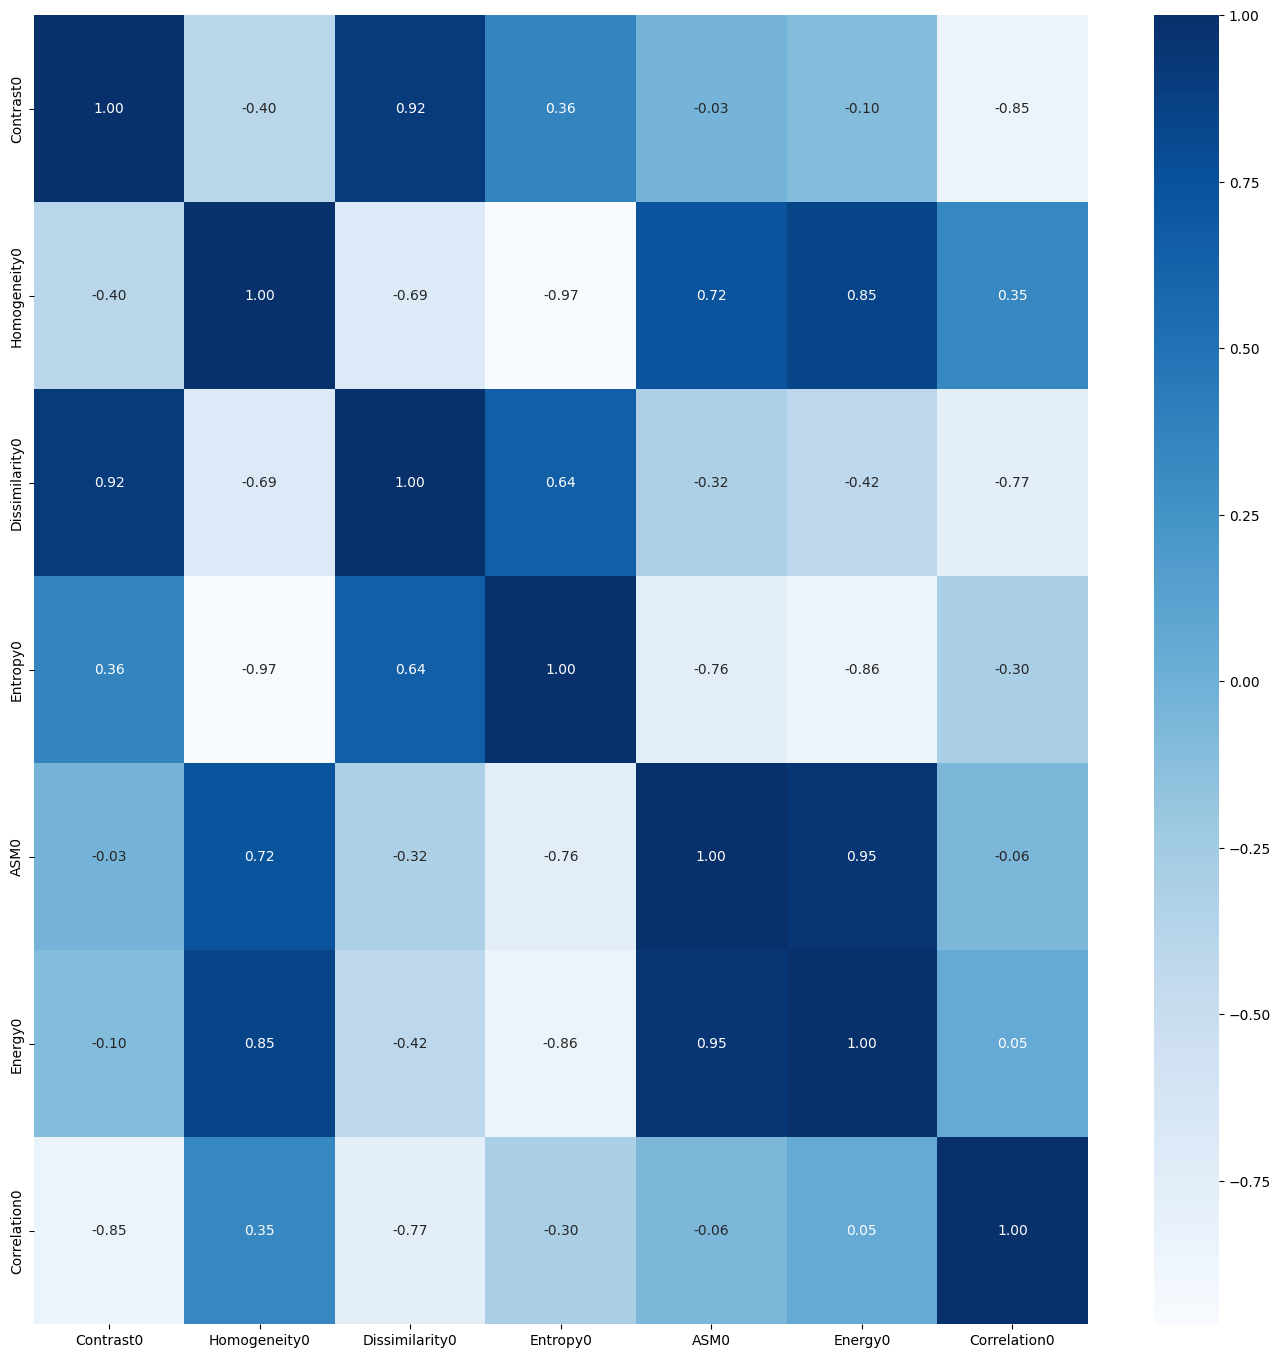

In [35]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

In [36]:

X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1440, 7)
(360, 7)
(1440,)
(360,)


In [37]:
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

In [38]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [39]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

      glioma       0.99      1.00      1.00       722
     notumor       1.00      0.99      1.00       718

    accuracy                           1.00      1440
   macro avg       1.00      1.00      1.00      1440
weighted avg       1.00      1.00      1.00      1440

[[720   2]
 [  4 714]]
Accuracy: 0.9958333333333333

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.97      0.93      0.95       178
     notumor       0.94      0.97      0.95       182

    accuracy                           0.95       360
   macro avg       0.95      0.95      0.95       360
weighted avg       0.95      0.95      0.95       360

[[166  12]
 [  6 176]]
Accuracy: 0.95


In [40]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      glioma       0.88      0.97      0.92       722
     notumor       0.96      0.87      0.91       718

    accuracy                           0.92      1440
   macro avg       0.92      0.92      0.92      1440
weighted avg       0.92      0.92      0.92      1440

[[699  23]
 [ 96 622]]
Accuracy: 0.9173611111111111

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.90      0.96      0.93       178
     notumor       0.96      0.89      0.92       182

    accuracy                           0.93       360
   macro avg       0.93      0.93      0.92       360
weighted avg       0.93      0.93      0.92       360

[[171   7]
 [ 20 162]]
Accuracy: 0.925


In [41]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      glioma       0.93      0.98      0.96       722
     notumor       0.98      0.93      0.95       718

    accuracy                           0.96      1440
   macro avg       0.96      0.96      0.96      1440
weighted avg       0.96      0.96      0.96      1440

[[710  12]
 [ 51 667]]
Accuracy: 0.95625

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.92      0.96      0.94       178
     notumor       0.95      0.92      0.94       182

    accuracy                           0.94       360
   macro avg       0.94      0.94      0.94       360
weighted avg       0.94      0.94      0.94       360

[[170   8]
 [ 14 168]]
Accuracy: 0.9388888888888889


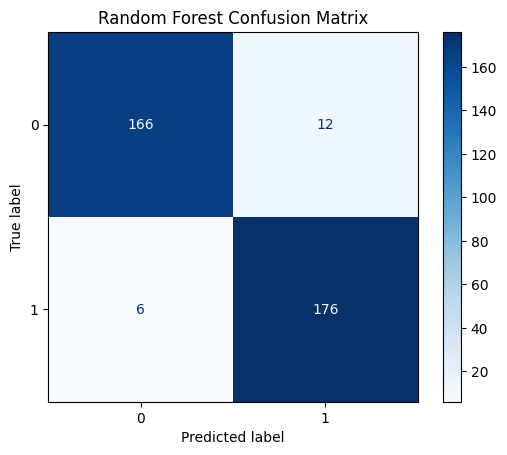

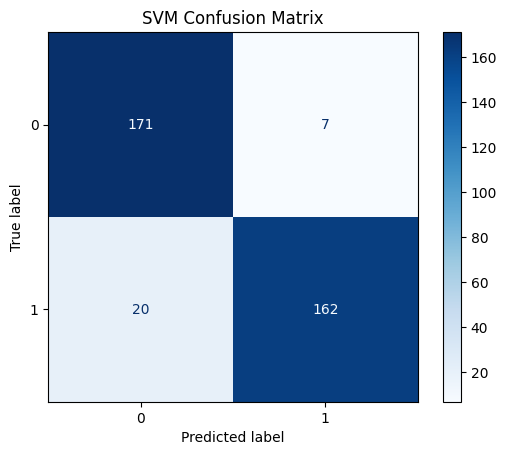

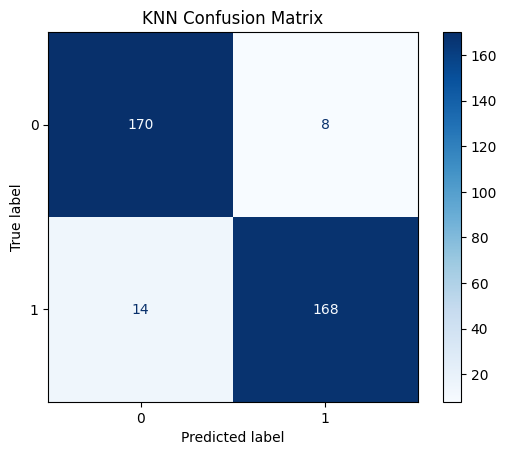

In [42]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")